# PipelineTS Quick Start Guide
# PipelineTS 快速入门指南

This tutorial walks you through the core features of PipelineTS:
本教程将带你快速了解 PipelineTS 的核心功能：

1. **Load built-in datasets / 加载内置数据集**
2. **Train a single model for time series forecasting / 使用单个模型进行时间序列预测**
3. **Use ModelPipeline for automatic model selection / 使用 ModelPipeline 自动选择最佳模型**
4. **Visualize prediction results / 可视化预测结果**
5. **Save and load models / 保存与加载模型**

## 1. Load Built-in Datasets
## 1. 加载内置数据集

PipelineTS comes with several built-in time series datasets for quick experimentation.
PipelineTS 内置了多个时间序列数据集，方便快速验证模型效果。

In [1]:
from PipelineTS.dataset import (
    LoadElectricDataSets,
    LoadMessagesSentDataSets,
    LoadWebSales,
    LoadSupermarketIncoming
)

# 加载电力数据集
data = LoadElectricDataSets()
print(f"数据形状: {data.shape}")
print(f"列名: {data.columns.tolist()}")
data.head()

数据形状: (397, 2)
列名: ['date', 'value']


,date,value
0,1985-01-01,72.5052
1,1985-02-01,70.6720
2,1985-03-01,62.4502
3,1985-04-01,57.4714
4,1985-05-01,55.3151


## 2. Train a Single Model
## 2. 使用单个模型进行预测

Here we use LightGBMModel as an example to demonstrate the basic usage of a single model.
以 LightGBMModel 为例，展示单个模型的基本用法。

In [ ]:
import pandas as pd

# Ensure the time column is in datetime format
# 确保时间列为 datetime 类型
time_col = data.columns[0]
target_col = data.columns[1]
data[time_col] = pd.to_datetime(data[time_col])

print(f"Time column / 时间列: {time_col}, Target column / 目标列: {target_col}")
print(f"Time range / 时间范围: {data[time_col].min()} ~ {data[time_col].max()}")

时间列: date, 目标列: value
时间范围: 1985-01-01 00:00:00 ~ 2018-01-01 00:00:00


In [ ]:
from PipelineTS.ml_model import LightGBMModel

# Initialize the model
# 初始化模型
model = LightGBMModel(
    time_col=time_col,
    target_col=target_col,
    lags=12,           # Use 12 past time steps as features / 使用过去12个时间步作为特征
    quantile=0.9,      # 90% prediction interval / 90% 预测区间
    n_estimators=200,
    verbose=-1
)

# Train the model
# 训练模型
model.fit(data)
print("Model training complete! / 模型训练完成！")

模型训练完成！


In [ ]:
# Predict the next 10 time steps
# 预测未来 10 个时间步
result = model.predict(10)
print(f"Prediction shape / 预测结果形状: {result.shape}")
result

预测结果形状: (10, 4)


,date,value,value_lower,value_upper
0,2018-01-02,99.504703,63.490345,135.519060
1,2018-01-03,62.740933,40.032716,85.449150
2,2018-01-04,89.932191,57.382472,122.481909
3,2018-01-05,63.683248,40.633973,86.732524
4,2018-01-06,-63.058729,-40.235490,-85.881968
5,2018-01-07,-0.346569,-0.221133,-0.472005
6,2018-01-08,78.384279,50.014168,106.754390
7,2018-01-09,66.132436,42.196711,90.068160
8,2018-01-10,81.922947,52.272064,111.573830
9,2018-01-11,46.509232,29.675855,63.342608


## 3. Visualize Prediction Results
## 3. 可视化预测结果

PipelineTS provides a modern visualization toolkit with Chinese font support.
PipelineTS 提供现代可视化工具包，支持中文字体。

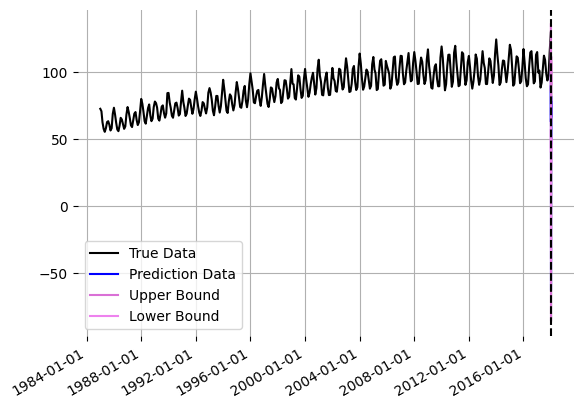

In [ ]:
from PipelineTS.plot import plot_forecast, plot_series

# Visualize raw data / 可视化原始数据
plot_series(data, time_col=time_col, target_col=target_col, title='原始时间序列', lang='zh')

# Visualize training data and prediction results with intervals
# 可视化训练数据与带区间的预测结果
plot_forecast(
    data, result,
    time_col=time_col, target_col=target_col,
    history_tail=60,
    title='LightGBM 预测结果',
    lang='zh',
)

## 4. Use ModelPipeline for Automatic Model Selection
## 4. 使用 ModelPipeline 自动选择最佳模型

ModelPipeline automatically trains multiple models and selects the best one.
ModelPipeline 会自动训练多个模型并选出效果最好的一个。

In [ ]:
from PipelineTS.pipeline import ModelPipeline

# List all available models
# 查看所有可用模型
print("All available models / 所有可用模型:")
ModelPipeline.list_all_available_models()

所有可用模型:


['auto_arima',
 'catboost',
 'd_linear',
 'gau',
 'itransformer',
 'lightgbm',
 'multi_output_model',
 'multi_step_model',
 'n_beats',
 'n_hits',
 'n_linear',
 'patch_rnn',
 'prophet',
 'random_forest',
 'regressor_chain',
 'srs_net',
 'stacking_rnn',
 'tcn',
 'tft',
 'tide',
 'time2vec',
 'transformer',
 'wide_gbrt',
 'xgboost']

In [ ]:
# Create Pipeline with 'ml' mode (machine learning models, faster)
# 创建 Pipeline，使用 'ml' 模式（机器学习模型集合，速度较快）
pipeline = ModelPipeline(
    time_col=time_col,
    target_col=target_col,
    lags=12,
    quantile=0.9,
    include_models='ml',  # Options: 'light', 'all', 'nn', 'ml'
                          # 选项：'light', 'all', 'nn', 'ml'
    cv=3
)

# Train all models and return leaderboard
# 训练所有模型并返回排行榜
leaderboard = pipeline.fit(data)
leaderboard


2026-02-09 22:41:22 - PipelineTS - INFO - Information about the device used for computation:
MPS  available: True   | MPS  use: True
CUDA available: False  | CUDA use: False
TPU  available: False  | TPU  use: False
CPU  available: True   | CPU  use: False


2026-02-09 22:41:22 - PipelineTS - INFO - There are a total of 7 models to be trained.
2026-02-09 22:41:22 - PipelineTS - INFO - [model 0] fitting and evaluating catboost...
2026-02-09 22:42:05 - PipelineTS - INFO - [model 1] fitting and evaluating lightgbm...
2026-02-09 22:42:56 - PipelineTS - INFO - [model 2] fitting and evaluating multi_output_model...
2026-02-09 22:43:11 - PipelineTS - INFO - [model 3] fitting and evaluating multi_step_model...
2026-02-09 22:43:22 - PipelineTS - INFO - [model 4] fitting and evaluating random_forest...
2026-02-09 22:43:45 - PipelineTS - INFO - [model 5] fitting and evaluating wide_gbrt...


Leaderboard,model,train_cost(s),eval_cost(s),metric,quantile_acc
0,xgboost,18.746918,3.148366,2.943096e+00,0.958333
1,catboost,33.804589,3.148683,3.234448e+00,0.916667
2,random_forest,12.649876,4.512487,3.375335e+00,0.958333
3,wide_gbrt,40.308780,4.092718,5.161023e+00,0.833333
4,multi_output_model,5.255882,3.115083,7.407570e+00,0.541667
5,multi_step_model,1.378630,3.110722,1.123114e+01,0.416667
6,lightgbm,41.772076,3.183761,5.053333e+190,0.333333


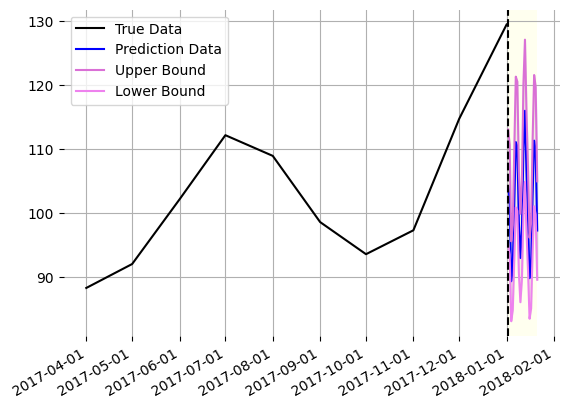

In [ ]:
from PipelineTS.plot import plot_forecast

# Predict using the best model / 使用最佳模型预测
best_result = pipeline.predict(20)

# Visualize with the new plot_forecast function / 使用新的 plot_forecast 函数可视化
plot_forecast(
    data, best_result,
    time_col=time_col, target_col=target_col,
    history_tail=60,
    title='Pipeline 最佳模型预测',
    lang='zh',
)

# One-line leaderboard chart / 一行代码绘制排行榜
pipeline.plot_leaderboard(lang='zh')

## 5. Save and Load Models
## 5. 保存与加载模型

In [ ]:
from PipelineTS.io import save_model, load_model

# Save Pipeline / 保存 Pipeline
save_model('my_pipeline.zip', pipeline)
print("Pipeline saved to my_pipeline.zip / Pipeline 已保存到 my_pipeline.zip")

# Load Pipeline / 加载 Pipeline
loaded_pipeline = load_model('my_pipeline.zip')
loaded_result = loaded_pipeline.predict(5)
loaded_result

In [ ]:
# You can also save a single model
# 也可以保存单个模型
best_model = pipeline.get_model()
save_model('best_model.zip', best_model)
print("Best model saved to best_model.zip / 最佳模型已保存到 best_model.zip")

## Summary / 总结

This tutorial covered the core workflow of PipelineTS:
本教程介绍了 PipelineTS 的核心工作流：

| Step / 步骤 | API |
|---|---|
| Load data / 加载数据 | `LoadElectricDataSets()` etc. |
| Single model prediction / 单模型预测 | `LightGBMModel(...).fit(data).predict(n)` |
| Auto model selection / 自动模型选择 | `ModelPipeline(...).fit(data).predict(n)` |
| Visualization / 可视化 | `plot_series()`, `plot_forecast()`, `pipeline.plot()` |
| Leaderboard / 排行榜 | `pipeline.plot_leaderboard()` |
| Save/Load / 保存/加载 | `save_model(path, model)` / `load_model(path)` |

For more advanced features, see the other tutorials:
更多高级功能请参考其他教程：

- **08**: Visualization toolkit / 可视化工具包
- **09**: Multi-quantile prediction intervals / 多分位数预测区间
- **10**: Multi-series (panel data) & covariates / 多序列与协变量
- **11**: Incremental learning / 增量学习